# Travel Reimbursement Approval Agent

An AI-assisted agent that reviews a travel reimbursement claim against the policy (Appendix A), calls tools to
check eligibility, receipts, per-diem limits, timeliness and approval tier, and returns a structured decision:
`APPROVE`, `PARTIAL_APPROVE`, `REJECT` or `MANUAL_REVIEW`.

**Contents**
1. README: setup, environment variables, how to run
2. Policy, limits and approval matrix (Appendix A, as data)
3. Claim intake (Appendix B, as validated JSON)
4. Tools: policy lookup plus five deterministic checks
5. Rule floor and output validator (the guardrail)
6. Agent: LLM tool-calling loop, plus a rules-only planner as the fallback
7. Run, audit trail and sample outputs
8. Evaluation against hand-derived expectations
9. Dashboard (static summary plus an interactive claim evaluator)
10. Design Notes & Reasoning
11. Final structured results (JSON)

## README

### Setup
```bash
python -m venv .venv && source .venv/bin/activate
pip install openai pydantic pandas matplotlib ipywidgets jupyter
jupyter lab aniketsharma.ipynb        # then Run -> Run All Cells
```
The first code cell installs any missing package, so **Run All** also works in a fresh kernel (Colab included).

### Environment variables (all optional)
The notebook runs with **no keys at all**. In that case a deterministic planner calls the same tools, and the output
is labelled `rules-only` in the audit trail. Set one of the following to turn on the LLM tool-calling agent. Every
provider is reached through the OpenAI-compatible Chat Completions API, so one code path covers all of them.

| Variable | Provider | Default model | Cost |
|---|---|---|---|
| `GROQ_API_KEY` | Groq | `llama-3.3-70b-versatile` | free tier |
| `GEMINI_API_KEY` | Google Gemini (OpenAI endpoint) | `gemini-2.5-flash` | free tier |
| `OPENAI_API_KEY` | OpenAI | `gpt-4o-mini` | paid |
| *(none, Ollama running on :11434)* | local Ollama | `qwen2.5:7b` | local |
| `LLM_BASE_URL` + `LLM_MODEL` (+ `LLM_API_KEY`) | any OpenAI-compatible server | – | – |
| `LLM_MODEL` | overrides the default model of whichever provider is picked | – | – |
| `RULES_ONLY=1` | forces the deterministic planner even when a key is set | – | – |

```bash
export GROQ_API_KEY=...   # free key from console.groq.com
jupyter lab aniketsharma.ipynb
```

### How to run the demo
* **Run All.** Section 7 evaluates the five Appendix B claims and prints each audit trail. Section 9 draws the dashboard
  and saves it as `UI SS_1.png`. The **last cell** prints the JSON results array.
* **Interactive UI.** In section 9, pick a sample claim or paste your own claim JSON, edit it, and press **Evaluate claim**.

### Key design choices (more detail in *Design Notes & Reasoning*)
* **The LLM orchestrates and explains. The tools do the arithmetic.** Amounts, caps and thresholds come only from
  deterministic Python tools, so a model cannot miscount a per-diem.
* **The LLM can escalate but never relax.** A validator recomputes a rule floor from the tool outputs. The agent may push a
  claim *to* Manual Review when it spots ambiguity the rules cannot see. It can never approve what the rules route to
  review, and it can never change an amount.
* **Fail toward Manual Review.** Missing or unstated receipts, policy exceptions, quantities that contradict the trip dates,
  unknown categories and amounts above the director tier all route to a human.

## 1. Setup

In [1]:
import importlib.util, subprocess, sys

REQUIRED = {"openai": "openai", "pydantic": "pydantic", "pandas": "pandas", "matplotlib": "matplotlib", "ipywidgets": "ipywidgets"}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import json, math, os, re, urllib.request
from datetime import date
from typing import Literal

import pandas as pd
from IPython.display import Markdown, display
from pydantic import BaseModel, ConfigDict, Field, ValidationError, model_validator

pd.set_option("display.max_colwidth", 120)


def money(x: float) -> str:
    return f"${x:,.2f}"

In [2]:
def detect_llm():
    """Pick the first configured OpenAI-compatible provider. None means rules-only mode."""
    if os.getenv("RULES_ONLY") == "1":
        return None
    if os.getenv("LLM_BASE_URL") and os.getenv("LLM_MODEL"):
        return {"name": "custom", "base_url": os.environ["LLM_BASE_URL"], "api_key": os.getenv("LLM_API_KEY", "none"), "model": os.environ["LLM_MODEL"]}
    hosted = [
        ("groq", "GROQ_API_KEY", "https://api.groq.com/openai/v1", "llama-3.3-70b-versatile"),
        ("gemini", "GEMINI_API_KEY", "https://generativelanguage.googleapis.com/v1beta/openai/", "gemini-2.5-flash"),
        ("openai", "OPENAI_API_KEY", None, "gpt-4o-mini"),
    ]
    for name, key_var, base_url, model in hosted:
        if os.getenv(key_var):
            return {"name": name, "base_url": base_url, "api_key": os.environ[key_var], "model": os.getenv("LLM_MODEL", model)}
    try:
        urllib.request.urlopen("http://localhost:11434/api/tags", timeout=1)
        return {"name": "ollama", "base_url": "http://localhost:11434/v1", "api_key": "ollama", "model": os.getenv("LLM_MODEL", "qwen2.5:7b")}
    except Exception:
        return None


LLM = detect_llm()
llm_client = None
if LLM:
    from openai import OpenAI
    llm_client = OpenAI(base_url=LLM["base_url"], api_key=LLM["api_key"], timeout=60, max_retries=2)

print(f"Agent mode: LLM tool-calling via {LLM['name']} / {LLM['model']}" if LLM
      else "Agent mode: rules-only planner (no LLM key found; set GROQ_API_KEY to enable the LLM agent)")

Agent mode: rules-only planner (no LLM key found; set GROQ_API_KEY to enable the LLM agent)


## 2. Policy, limits and approval matrix

The policy from Appendix A is stored as data. Each rule keeps its stable `POL-*` id, which the tools return and the output
cites. The `keywords` field is the only thing added: it gives the policy-lookup tool a few synonyms (for example "dinner"
for meals, "hotel" for lodging).

In [3]:
POLICY = [
    {"id": "POL-CAT-01", "title": "Eligible categories",
     "text": "Reimbursable when incurred for a documented business purpose: airfare (economy class only, see POL-AIR-01); lodging (hotel room charges); meals (subject to per-diem limits, see POL-PD-01); ground transport (taxi, rideshare, train, rental car, parking); conference / registration fees.",
     "keywords": "eligible reimbursable business purpose airfare flight lodging hotel meal ground transport taxi rideshare train rental car parking conference registration fee"},
    {"id": "POL-CAT-02", "title": "Ineligible items",
     "text": "Never reimbursable; rejected (deducted in full): alcohol and minibar charges; spa, gym, and personal entertainment; in-room movies, personal shopping, gifts; traffic fines, penalties, and late fees; any personal (non-business) expense.",
     "keywords": "ineligible alcohol minibar spa gym entertainment movie shopping gift fine penalty late fee personal weekend"},
    {"id": "POL-PD-01", "title": "Meals per diem",
     "text": "Meals: maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.",
     "keywords": "meal dinner lunch breakfast food per diem daily cap"},
    {"id": "POL-PD-02", "title": "Lodging limit",
     "text": "Lodging: maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.",
     "keywords": "lodging hotel night nightly room cap"},
    {"id": "POL-PD-03", "title": "Ground transport limit",
     "text": "Ground transport: maximum $50 per day. Amounts above the cap are deducted.",
     "keywords": "ground transport taxi rideshare uber train rental car parking daily cap"},
    {"id": "POL-AIR-01", "title": "Airfare class",
     "text": "Only economy class airfare is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review (not auto-deducted, because a pre-approval may exist).",
     "keywords": "airfare flight economy business first class exception pre-approval"},
    {"id": "POL-RCT-01", "title": "Receipt required above $25",
     "text": "Any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount.",
     "keywords": "receipt itemized attached threshold airfare lodging"},
    {"id": "POL-RCT-02", "title": "Missing receipt handling",
     "text": "If a receipt is missing for an item that requires one, the item is not silently rejected; the claim is routed to Manual Review so the reviewer can request the receipt.",
     "keywords": "receipt missing manual review request"},
    {"id": "POL-APR-01", "title": "Auto-approve tier",
     "text": "Thresholds are evaluated on the total reimbursable amount (after per-diem deductions). Total <= $500: may be auto-approved by the agent if fully compliant.",
     "keywords": "approval threshold tier total auto approve"},
    {"id": "POL-APR-02", "title": "Manager tier",
     "text": "Total > $500 and <= $2,000: eligible for approval, treated as approvable when fully compliant.",
     "keywords": "approval threshold tier total manager"},
    {"id": "POL-APR-03", "title": "Director / Manual-Review tier",
     "text": "Total > $2,000: exceeds the agent's auto-approval authority and must be routed to Manual Review (director approval required), even if otherwise compliant.",
     "keywords": "approval threshold tier total director high value manual review"},
    {"id": "POL-TIME-01", "title": "Submission window",
     "text": "Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review.",
     "keywords": "submission window late deadline days timeliness date"},
]
POLICY_BY_ID = {r["id"]: r for r in POLICY}

DECISION_GUIDANCE = """\
APPROVE: every item eligible, all receipts present, all within per-diem, total within an approvable tier (POL-APR-01 / POL-APR-02).
PARTIAL_APPROVE: the claim is valid but some amounts exceed per-diem caps; reimburse up to the cap and deduct the excess.
REJECT: the claimed items are ineligible (POL-CAT-02) with nothing reimbursable.
MANUAL_REVIEW: any ambiguity, policy exception, high value (POL-APR-03), missing required receipt (POL-RCT-02), or conflicting information. Prefer Manual Review over forcing a decision."""

# Limit table / category eligibility file
CATEGORY_RULES = {
    "airfare":          {"cap": None,  "unit": None,    "cap_rule": None,        "always_receipt": True},
    "lodging":          {"cap": 200.0, "unit": "night", "cap_rule": "POL-PD-02", "always_receipt": True},
    "meals":            {"cap": 75.0,  "unit": "day",   "cap_rule": "POL-PD-01", "always_receipt": False},
    "ground_transport": {"cap": 50.0,  "unit": "day",   "cap_rule": "POL-PD-03", "always_receipt": False},
    "conference_fees":  {"cap": None,  "unit": None,    "cap_rule": None,        "always_receipt": False},
}
INELIGIBLE_CATEGORIES = {"alcohol", "minibar", "spa", "gym", "entertainment", "in_room_movies", "personal_shopping",
                         "gifts", "traffic_fines", "penalties", "late_fees", "personal"}
CATEGORY_ALIASES = {"flight": "airfare", "hotel": "lodging", "meal": "meals", "taxi": "ground_transport",
                    "rideshare": "ground_transport", "train": "ground_transport", "rental_car": "ground_transport",
                    "parking": "ground_transport", "conference": "conference_fees", "registration": "conference_fees",
                    "movies": "in_room_movies", "gift": "gifts", "fine": "traffic_fines", "bar": "alcohol"}
RECEIPT_THRESHOLD = 25.0
SUBMISSION_WINDOW_DAYS = 30
APPROVAL_TIERS = [(500.0, "POL-APR-01", "auto-approve"), (2000.0, "POL-APR-02", "manager"), (math.inf, "POL-APR-03", "director")]

display(pd.DataFrame([{"category": c, **v} for c, v in CATEGORY_RULES.items()]))
display(pd.DataFrame([{"max_total": t, "rule": r, "tier": n} for t, r, n in APPROVAL_TIERS]))

,category,cap,unit,cap_rule,always_receipt
0,airfare,NaN,NaN,NaN,True
1,lodging,200.0,night,POL-PD-02,True
2,meals,75.0,day,POL-PD-01,False
3,ground_transport,50.0,day,POL-PD-03,False
4,conference_fees,NaN,NaN,NaN,False


,max_total,rule,tier
0,500.0,POL-APR-01,auto-approve
1,2000.0,POL-APR-02,manager
2,inf,POL-APR-03,director


## 3. Claim intake

The five Appendix B claims, transcribed as JSON with no changes, then validated by a Pydantic schema. The same schema checks
claims pasted into the interactive UI. `receipt_attached` is three-valued: `true`, `false`, or `null` when **the claim does not
say**.

> **Transcription note, CLM-005.** The Appendix B row for CLM-005 gives no line amount and no *Receipt attached* value. It
> has one line item and a total of $220.00, so the line amount is taken from the total. The receipt status is recorded as
> `null` (not stated) rather than guessed in either direction, and the agent has to handle the gap.

In [4]:
CLAIMS_JSON = r"""
[
  {"claim_id": "CLM-001", "employee": "A. Rivera", "purpose": "Attend 2-day industry conference (business)",
   "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20", "total_claimed": 1110.00,
   "items": [
     {"line": 1, "category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": true},
     {"line": 2, "category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": true},
     {"line": 3, "category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": true},
     {"line": 4, "category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": true}]},
  {"claim_id": "CLM-002", "employee": "B. Osei", "purpose": "Weekend hotel stay",
   "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25", "total_claimed": 380.00,
   "items": [
     {"line": 1, "category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": true},
     {"line": 2, "category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": true}]},
  {"claim_id": "CLM-003", "employee": "C. Nakamura", "purpose": "Client site visit (business)",
   "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22", "total_claimed": 940.00,
   "items": [
     {"line": 1, "category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": true},
     {"line": 2, "category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": true},
     {"line": 3, "category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": true}]},
  {"claim_id": "CLM-004", "employee": "D. Fischer", "purpose": "International vendor negotiation (business)",
   "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28", "total_claimed": 3000.00,
   "items": [
     {"line": 1, "category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": true},
     {"line": 2, "category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": false}]},
  {"claim_id": "CLM-005", "employee": "E. Haddad", "purpose": "Client dinner / business development",
   "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24", "total_claimed": 220.00,
   "items": [
     {"line": 1, "category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": null}]}
]
"""


class LineItem(BaseModel):
    model_config = ConfigDict(extra="forbid")
    line: int
    category: str = Field(min_length=1)
    description: str
    amount: float = Field(ge=0)
    receipt_attached: bool | None  # None = the claim does not say


class Claim(BaseModel):
    model_config = ConfigDict(extra="forbid")
    claim_id: str = Field(min_length=1)
    employee: str
    purpose: str
    trip_start: date
    trip_end: date
    submitted: date
    total_claimed: float = Field(ge=0)
    items: list[LineItem] = Field(min_length=1)


CLAIM_STORE: dict[str, Claim] = {}


def intake(raw) -> list[str]:
    """Validate one claim or a list of claims (dict, list, or JSON string) and register them. Returns the claim ids."""
    data = json.loads(raw) if isinstance(raw, str) else raw
    claims = [Claim.model_validate(c) for c in (data if isinstance(data, list) else [data])]
    for c in claims:
        CLAIM_STORE[c.claim_id] = c
    return [c.claim_id for c in claims]


SAMPLE_IDS = intake(CLAIMS_JSON)
pd.DataFrame([{"claim_id": c.claim_id, "employee": c.employee, "purpose": c.purpose, "trip": f"{c.trip_start} → {c.trip_end}",
               "submitted": c.submitted, "lines": len(c.items), "total_claimed": c.total_claimed} for c in CLAIM_STORE.values()])

,claim_id,employee,purpose,trip,submitted,lines,total_claimed
0,CLM-001,A. Rivera,Attend 2-day industry conference (business),2026-06-10 → 2026-06-12,2026-06-20,4,1110.0
1,CLM-002,B. Osei,Weekend hotel stay,2026-06-14 → 2026-06-15,2026-06-25,2,380.0
2,CLM-003,C. Nakamura,Client site visit (business),2026-06-08 → 2026-06-10,2026-06-22,3,940.0
3,CLM-004,D. Fischer,International vendor negotiation (business),2026-06-16 → 2026-06-18,2026-06-28,2,3000.0
4,CLM-005,E. Haddad,Client dinner / business development,2026-06-11 → 2026-06-11,2026-06-24,1,220.0


## 4. Tools

Six tools. The agent sees them as OpenAI-style function schemas.

| Tool | What it does | Policy grounding |
|---|---|---|
| `lookup_policy(query)` | keyword retrieval over the policy rules; returns rule ids and text | context for the LLM |
| `check_eligibility(claim_id)` | sorts each line into eligible, ineligible or unknown category, and checks the stated total | POL-CAT-01/02 |
| `check_receipts(claim_id)` | receipt requirement per line: present, missing, or not stated | POL-RCT-01/02 |
| `check_limits(claim_id)` | per-diem caps sized from trip dates, quantity conflicts, airfare class, multi-attendee meals | POL-PD-01/02/03, POL-AIR-01 |
| `check_timeliness(claim_id)` | 30-day submission window and date sanity | POL-TIME-01 |
| `check_approval_tier(amount)` | maps a reimbursable total to its approval tier | POL-APR-01/02/03 |

Claim-scoped tools take only a `claim_id` and read the validated claim from the store. The model never passes amounts in,
so it cannot change them. Every tool is pure and deterministic.

In [5]:
_STOP = {"the", "a", "an", "and", "or", "of", "for", "to", "is", "are", "what", "rules", "rule", "policy", "on", "in", "with", "per"}


def _tokens(text: str) -> set[str]:
    words = re.findall(r"[a-z0-9]+", text.lower())
    return {w[:-1] if len(w) > 3 and w.endswith("s") else w for w in words} - _STOP


def lookup_policy(query: str, k: int = 3) -> dict:
    """Return the k policy rules most relevant to the query (keyword overlap; an exact POL id always ranks first)."""
    q = _tokens(query)
    scored = []
    for rule in POLICY:
        score = len(q & _tokens(f"{rule['title']} {rule['text']} {rule['keywords']}"))
        if rule["id"].lower() in query.lower():
            score += 10
        if score:
            scored.append((score, rule))
    scored.sort(key=lambda s: -s[0])
    return {"query": query, "rules": [{"id": r["id"], "title": r["title"], "text": r["text"]} for _, r in scored[:k]]}


def _category(raw: str) -> str:
    c = re.sub(r"[\s\-]+", "_", raw.strip().lower())
    return CATEGORY_ALIASES.get(c, c)


def check_eligibility(claim_id: str) -> dict:
    """Classify each line as eligible (POL-CAT-01), ineligible (POL-CAT-02) or unknown category."""
    claim = CLAIM_STORE[claim_id]
    items = []
    for it in claim.items:
        cat = _category(it.category)
        status = "eligible" if cat in CATEGORY_RULES else "ineligible" if cat in INELIGIBLE_CATEGORIES else "unknown_category"
        items.append({"line": it.line, "category": cat, "description": it.description, "amount": it.amount, "status": status,
                      "rule": "POL-CAT-02" if status == "ineligible" else "POL-CAT-01"})
    total = lambda s: round(sum(i["amount"] for i in items if i["status"] == s), 2)
    line_sum = round(sum(it.amount for it in claim.items), 2)
    return {"claim_id": claim_id, "purpose": claim.purpose, "items": items,
            "eligible_total": total("eligible"), "ineligible_total": total("ineligible"), "unknown_total": total("unknown_category"),
            "line_items_sum": line_sum, "total_claimed": claim.total_claimed, "total_matches": abs(line_sum - claim.total_claimed) < 0.01}


def check_receipts(claim_id: str) -> dict:
    """POL-RCT-01: receipt needed if amount > $25, and always for airfare/lodging. Ineligible lines are skipped (deducted anyway)."""
    claim = CLAIM_STORE[claim_id]
    items, missing_docs = [], []
    for it in claim.items:
        cat = _category(it.category)
        if cat in INELIGIBLE_CATEGORIES:
            continue
        required = it.amount > RECEIPT_THRESHOLD or CATEGORY_RULES.get(cat, {}).get("always_receipt", False)
        status = ("not_required" if not required else "present" if it.receipt_attached
                  else "missing" if it.receipt_attached is False else "not_stated")
        items.append({"line": it.line, "category": cat, "amount": it.amount, "required": required, "status": status})
        if status == "missing":
            missing_docs.append(f"Itemized receipt for line {it.line}: {it.description} ({money(it.amount)})")
        elif status == "not_stated":
            missing_docs.append(f"Itemized receipt for line {it.line}: {it.description} ({money(it.amount)}); attachment status not stated on the claim")
    return {"claim_id": claim_id, "items": items, "missing_docs": missing_docs,
            "all_required_present": not missing_docs, "rules": ["POL-RCT-01", "POL-RCT-02"] if missing_docs else ["POL-RCT-01"]}


_QTY = {"night": re.compile(r"(\d+)\s*nights?\b", re.I), "day": re.compile(r"(\d+)\s*days?\b", re.I)}
_ATTENDEES = re.compile(r"\bfor\s+(\d+)\b|\b(\d+)\s+(?:people|persons|guests|attendees|pax)\b", re.I)
_PREMIUM_CLASS = re.compile(r"\b(business|first)[\s-]*class\b", re.I)


def check_limits(claim_id: str) -> dict:
    """Apply per-diem caps (POL-PD-*) sized from the trip dates, and check airfare class (POL-AIR-01).

    An excess is a *certain* deduction only when nothing about the line is ambiguous. A line whose stated quantity exceeds
    the trip, or a meal for several attendees, gets `uncertain: true` and its excess is left for the reviewer.
    """
    claim = CLAIM_STORE[claim_id]
    nights = (claim.trip_end - claim.trip_start).days
    trip_units = {"night": nights, "day": nights + 1}
    items, airfare = [], []
    for it in claim.items:
        cat = _category(it.category)
        rule = CATEGORY_RULES.get(cat)
        if rule is None:
            continue
        row = {"line": it.line, "category": cat, "amount": it.amount, "allowed": it.amount, "excess": 0.0, "uncertain": False, "notes": []}
        if rule["cap"]:
            unit, units = rule["unit"], trip_units[rule["unit"]]
            m = _QTY[unit].search(it.description)
            stated = int(m.group(1)) if m else None
            if stated is not None and stated > units:
                row["uncertain"] = True
                row["notes"].append(f"description states {stated} {unit}(s) but the trip dates allow {units}")
            elif stated is not None:
                units = stated
            if units == 0:
                row["uncertain"] = True
                row["notes"].append(f"{cat} claimed on a same-day trip (0 {unit}s)")
            row.update(cap_rule=rule["cap_rule"], cap=f"{money(rule['cap'])}/{unit}", units=units,
                       allowed=round(min(it.amount, rule["cap"] * units), 2))
            row["excess"] = round(it.amount - row["allowed"], 2)
        if cat == "meals" and (m := _ATTENDEES.search(it.description)) and int(m.group(1) or m.group(2)) > 1:
            row["uncertain"] = True
            row["notes"].append(f"meal covers {int(m.group(1) or m.group(2))} attendees; POL-PD-01 is a per-day cap and the policy does not address hosting clients")
        if cat == "airfare":
            cls = _PREMIUM_CLASS.search(it.description)
            fare_class = cls.group(1).lower() if cls else "economy" if "economy" in it.description.lower() else "not_stated"
            row["fare_class"] = fare_class
            if fare_class != "economy":
                airfare.append({"line": it.line, "amount": it.amount, "fare_class": fare_class, "rule": "POL-AIR-01"})
                row["notes"].append(f"{fare_class} fare: policy exception, routed to Manual Review, not auto-deducted")
        items.append(row)
    certain = round(sum(r["excess"] for r in items if not r["uncertain"]), 2)
    eligible_total = round(sum(r["amount"] for r in items), 2)
    return {"claim_id": claim_id, "trip_days": nights + 1, "trip_nights": nights, "items": items,
            "certain_deductions": certain,
            "uncertain_lines": [r["line"] for r in items if r["uncertain"]],
            "airfare_exceptions": airfare,
            "reimbursable_total": round(eligible_total - certain, 2)}


def check_timeliness(claim_id: str) -> dict:
    """POL-TIME-01. Lines carry no dates, so the trip start is used as the expense date (the strictest reading)."""
    claim = CLAIM_STORE[claim_id]
    age = (claim.submitted - claim.trip_start).days
    conflict = claim.submitted < claim.trip_end or claim.trip_end < claim.trip_start
    return {"claim_id": claim_id, "days_since_expense": age, "window_days": SUBMISSION_WINDOW_DAYS,
            "within_window": age <= SUBMISSION_WINDOW_DAYS, "date_conflict": conflict, "rule": "POL-TIME-01"}


def check_approval_tier(amount: float) -> dict:
    """POL-APR-*: map a reimbursable total (after per-diem deductions) to its approval tier."""
    for limit, rule, tier in APPROVAL_TIERS:
        if amount <= limit:
            return {"amount": round(amount, 2), "tier": tier, "rule": rule, "agent_may_approve": tier != "director"}


TOOLS = {f.__name__: f for f in (lookup_policy, check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier)}
CLAIM_SCOPED = {"check_eligibility", "check_receipts", "check_limits", "check_timeliness"}

check_limits("CLM-003")

{'claim_id': 'CLM-003',
 'trip_days': 3,
 'trip_nights': 2,
 'items': [{'line': 1,
   'category': 'airfare',
   'amount': 300.0,
   'allowed': 300.0,
   'excess': 0.0,
   'uncertain': False,
   'notes': [],
   'fare_class': 'economy'},
  {'line': 2,
   'category': 'lodging',
   'amount': 500.0,
   'allowed': 400.0,
   'excess': 100.0,
   'uncertain': False,
   'notes': [],
   'cap_rule': 'POL-PD-02',
   'cap': '$200.00/night',
   'units': 2},
  {'line': 3,
   'category': 'meals',
   'amount': 140.0,
   'allowed': 140.0,
   'excess': 0.0,
   'uncertain': False,
   'notes': [],
   'cap_rule': 'POL-PD-01',
   'cap': '$75.00/day',
   'units': 2}],
 'certain_deductions': 100.0,
 'uncertain_lines': [],
 'airfare_exceptions': [],
 'reimbursable_total': 840.0}

## 5. Rule floor and output validator

`rule_floor` combines the tool outputs into the decision the policy forces. It also collects **reason codes** for every
Manual Review trigger. It is the guardrail the agent's proposal is checked against.

| Code | Trigger | Rule | Hard or soft |
|---|---|---|---|
| `RCT_MISSING` | required receipt marked not attached | POL-RCT-02 | hard |
| `RCT_NOT_STATED` | required receipt, attachment status unknown | POL-RCT-01/02 | soft |
| `AIR_CLASS` | business or first class, or class not stated | POL-AIR-01 | hard |
| `HIGH_VALUE` | reimbursable total > $2,000 | POL-APR-03 | hard |
| `LATE` | submitted more than 30 days after the expense | POL-TIME-01 | hard |
| `QTY_CONFLICT` | stated nights/days exceed the trip dates, or lodging on a same-day trip | – | soft |
| `MULTI_ATTENDEE` | meal for several people; per-diem cap does not clearly apply | POL-PD-01 | soft |
| `UNKNOWN_CATEGORY` | category is in neither list | POL-CAT-01 | soft |
| `DATE_CONFLICT` / `TOTAL_MISMATCH` | inconsistent dates or a total that does not match the lines | – | soft |
| `AGENT_ESCALATION` | the LLM raised a concern the rules cannot see and chose review | – | soft |

**Confidence** is a calibrated heuristic, not the model's opinion of itself. It is 0.95 when the decision follows from
hard rules alone, 0.80 when it rests on a soft (ambiguity) trigger, 0.75 when only the LLM's escalation drives it, and 0.60
when the validator had to override the LLM.

In [6]:
DECISIONS = ("APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW")
HARD_CODES = {"RCT_MISSING", "AIR_CLASS", "HIGH_VALUE", "LATE"}


def _order_refs(refs) -> list[str]:
    return [r["id"] for r in POLICY if r["id"] in set(refs)]


def rule_floor(claim_id: str) -> dict:
    """Combine the deterministic checks into the decision the policy forces, with reasons and reason codes."""
    claim = CLAIM_STORE[claim_id]
    elig, rct, lim, tim = check_eligibility(claim_id), check_receipts(claim_id), check_limits(claim_id), check_timeliness(claim_id)
    refs, reasons, codes, missing_docs = set(), [], [], list(rct["missing_docs"])

    ineligible = [i for i in elig["items"] if i["status"] == "ineligible"]
    if ineligible:
        refs.add("POL-CAT-02")
        reasons.append("Ineligible items deducted in full: " + ", ".join(f"{i['description'].lower()} {money(i['amount'])}" for i in ineligible) + " (POL-CAT-02).")
    if any(i["status"] == "eligible" for i in elig["items"]):
        refs.add("POL-CAT-01")
    for i in elig["items"]:
        if i["status"] == "unknown_category":
            codes.append("UNKNOWN_CATEGORY")
            reasons.append(f"Line {i['line']} category '{i['category']}' is not in the policy's eligible or ineligible lists.")

    for r in lim["items"]:
        if r.get("cap_rule"):
            refs.add(r["cap_rule"])
            label = f"{r['category'].replace('_', ' ').capitalize()} {money(r['amount'])} for {r['units']} {('night' if r['category'] == 'lodging' else 'day')}(s)"
            if r["uncertain"]:
                pass  # explained by its note below
            elif r["excess"] > 0:
                reasons.append(f"{label} exceeds the {r['cap']} cap ({money(r['allowed'])} allowed); {money(r['excess'])} deducted ({r['cap_rule']}).")
            else:
                reasons.append(f"{label} is within the {r['cap']} cap ({r['cap_rule']}).")
        for note in r["notes"]:
            if "attendees" in note:
                codes.append("MULTI_ATTENDEE")
                reasons.append(f"Line {r['line']}: {note}, so the {money(r['excess'])} above the cap is not deducted automatically.")
            elif "trip dates" in note or "same-day" in note:
                codes.append("QTY_CONFLICT")
                reasons.append(f"Line {r['line']}: {note}; the {money(r['amount'])} cannot be checked against {r.get('cap_rule')} until that is resolved.")
    for a in lim["airfare_exceptions"]:
        codes.append("AIR_CLASS")
        refs.add("POL-AIR-01")
        reasons.append(f"Line {a['line']}: {a['fare_class']}-class airfare {money(a['amount'])} is a policy exception; it needs Manual Review and is not auto-deducted, because a pre-approval may exist (POL-AIR-01).")
        missing_docs.append(f"Pre-approval for {a['fare_class']}-class airfare, line {a['line']} ({money(a['amount'])}), if one exists")

    for i in rct["items"]:
        if i["status"] == "missing":
            codes.append("RCT_MISSING")
            reasons.append(f"Line {i['line']} ({i['category']}, {money(i['amount'])}) requires a receipt that is not attached (POL-RCT-01); route to review so it can be requested (POL-RCT-02).")
        elif i["status"] == "not_stated":
            codes.append("RCT_NOT_STATED")
            reasons.append(f"Line {i['line']} ({i['category']}, {money(i['amount'])}) requires an itemized receipt (POL-RCT-01), but the claim does not state whether one is attached (POL-RCT-02).")
    if rct["missing_docs"]:
        refs.update(rct["rules"])

    if not tim["within_window"]:
        codes.append("LATE")
        reasons.append(f"Submitted {tim['days_since_expense']} days after the expense date, outside the 30-day window (POL-TIME-01).")
        refs.add("POL-TIME-01")
    if tim["date_conflict"]:
        codes.append("DATE_CONFLICT")
        reasons.append("Trip and submission dates are inconsistent.")
    if not elig["total_matches"]:
        codes.append("TOTAL_MISMATCH")
        reasons.append(f"Line items sum to {money(elig['line_items_sum'])} but the claim total is {money(elig['total_claimed'])}.")

    reimbursable = lim["reimbursable_total"]
    tier = check_approval_tier(reimbursable)
    has_eligible = elig["eligible_total"] > 0 or elig["unknown_total"] > 0
    if has_eligible:
        refs.add(tier["rule"])
        if tier["tier"] == "director":
            codes.append("HIGH_VALUE")
            reasons.append(f"Reimbursable total {money(reimbursable)} exceeds $2,000, beyond the agent's approval authority; director approval required (POL-APR-03).")
        else:
            reasons.append(f"Reimbursable total {money(reimbursable)} {'would fall' if codes else 'falls'} in the {tier['tier']} tier ({tier['rule']}).")

    certain = round(elig["ineligible_total"] + lim["certain_deductions"], 2)
    if codes:
        decision, approved, deducted = "MANUAL_REVIEW", 0.0, certain
    elif not has_eligible:
        decision, approved, deducted = "REJECT", 0.0, round(claim.total_claimed, 2)
    elif certain > 0:
        decision, approved, deducted = "PARTIAL_APPROVE", reimbursable, certain
    else:
        decision, approved, deducted = "APPROVE", reimbursable, 0.0

    codes = list(dict.fromkeys(codes))
    confidence = 0.95 if not codes or set(codes) & HARD_CODES else 0.80
    return {"decision": decision, "approved_amount": approved, "deducted_amount": deducted, "reimbursable_total": reimbursable,
            "missing_docs": missing_docs, "policy_refs": _order_refs(refs), "reasons": reasons, "review_codes": codes,
            "confidence": confidence}


def floor_explanation(floor: dict) -> str:
    lead = {"APPROVE": "Approved in full.", "PARTIAL_APPROVE": f"Partially approved: {money(floor['approved_amount'])} reimbursed, {money(floor['deducted_amount'])} deducted.",
            "REJECT": "Rejected: nothing in the claim is reimbursable.",
            "MANUAL_REVIEW": f"Routed to Manual Review ({', '.join(floor['review_codes'])}); nothing is approved until a reviewer resolves it."}[floor["decision"]]
    return " ".join([lead, *floor["reasons"]])


rule_floor("CLM-004")

{'decision': 'MANUAL_REVIEW',
 'approved_amount': 0.0,
 'deducted_amount': 0.0,
 'reimbursable_total': 3000.0,
 'missing_docs': ['Itemized receipt for line 2: Hotel, 3 nights ($600.00)',
  'Pre-approval for business-class airfare, line 1 ($2,400.00), if one exists'],
 'policy_refs': ['POL-CAT-01',
  'POL-PD-02',
  'POL-AIR-01',
  'POL-RCT-01',
  'POL-RCT-02',
  'POL-APR-03'],
 'reasons': ['Line 2: description states 3 night(s) but the trip dates allow 2; the $600.00 cannot be checked against POL-PD-02 until that is resolved.',
  'Line 1: business-class airfare $2,400.00 is a policy exception; it needs Manual Review and is not auto-deducted, because a pre-approval may exist (POL-AIR-01).',
  'Line 2 (lodging, $600.00) requires a receipt that is not attached (POL-RCT-01); route to review so it can be requested (POL-RCT-02).',
  "Reimbursable total $3,000.00 exceeds $2,000, beyond the agent's approval authority; director approval required (POL-APR-03)."],
 'review_codes': ['QTY_CONFLICT',

In [7]:
class ClaimDecision(BaseModel):
    """The exact output contract. extra='forbid' rejects any field outside the spec."""
    model_config = ConfigDict(extra="forbid")
    claim_id: str
    decision: Literal["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
    approved_amount: float = Field(ge=0)
    deducted_amount: float = Field(ge=0)
    missing_docs: list[str]
    policy_refs: list[str]
    confidence: float = Field(ge=0, le=1)
    explanation: str = Field(min_length=20)
    tools_used: list[str] = Field(min_length=1)

    @model_validator(mode="after")
    def _consistent(self):
        unknown = set(self.policy_refs) - set(POLICY_BY_ID)
        assert not unknown, f"unknown policy refs {unknown}"
        if self.decision == "APPROVE":
            assert self.deducted_amount == 0 and self.approved_amount > 0, "APPROVE needs approved > 0 and no deduction"
        if self.decision == "PARTIAL_APPROVE":
            assert self.deducted_amount > 0 and self.approved_amount > 0, "PARTIAL_APPROVE needs both amounts > 0"
        if self.decision in ("REJECT", "MANUAL_REVIEW"):
            assert self.approved_amount == 0, f"{self.decision} cannot approve money"
        return self


def validate_decision(claim_id: str, proposal: dict, floor: dict, trace: list) -> tuple[dict, list[str]]:
    """Reconcile the agent's proposal with the rule floor. The agent may escalate to MANUAL_REVIEW, but never relax a
    decision or change an amount. Returns the validated output and the validator's notes for the audit trail."""
    notes = []
    proposed = proposal.get("decision") if proposal.get("decision") in DECISIONS else None
    concerns = [str(c).strip() for c in proposal.get("concerns") or [] if str(c).strip()]
    decision, confidence = floor["decision"], floor["confidence"]
    explanation = (proposal.get("explanation") or "").strip()

    if proposed is None:
        notes.append(f"agent returned no valid decision ({proposal.get('decision')!r}); rule floor used")
        explanation = ""
    elif proposed == floor["decision"]:
        notes.append("agent decision matches the rule floor")
    elif proposed == "MANUAL_REVIEW":
        decision, confidence = "MANUAL_REVIEW", 0.75
        floor = {**floor, "review_codes": floor["review_codes"] + ["AGENT_ESCALATION"]}
        notes.append(f"agent escalated {floor['decision']} -> MANUAL_REVIEW: {concerns or 'no concern given'}")
    else:
        confidence = 0.60
        notes.append(f"OVERRIDE: agent proposed {proposed}, but the tool outputs force {floor['decision']}")
        explanation = ""
    if concerns and proposed != "MANUAL_REVIEW":
        notes.append(f"agent concerns recorded (not decisive): {concerns}")

    amounts = {"approved_amount": floor["approved_amount"], "deducted_amount": floor["deducted_amount"]}
    if decision == "MANUAL_REVIEW":
        amounts["approved_amount"] = 0.0
    if not explanation or not re.search(r"POL-[A-Z]+-\d+", explanation):
        explanation = floor_explanation({**floor, "decision": decision, **amounts})
        if proposed:
            notes.append("explanation taken from rule floor (agent text missing, overridden or uncited)")
    agent_refs = [r for r in proposal.get("policy_refs") or [] if r in POLICY_BY_ID]
    if dropped := set(proposal.get("policy_refs") or []) - set(agent_refs):
        notes.append(f"dropped unknown policy refs {sorted(dropped)}")

    claimed = CLAIM_STORE[claim_id].total_claimed
    assert amounts["approved_amount"] + amounts["deducted_amount"] <= claimed + 0.01, "approved + deducted exceeds the claimed total"
    out = ClaimDecision(
        claim_id=claim_id, decision=decision, **amounts,
        missing_docs=floor["missing_docs"],
        policy_refs=_order_refs(set(floor["policy_refs"]) | set(agent_refs)),
        confidence=confidence, explanation=explanation,
        tools_used=list(dict.fromkeys(t["tool"] for t in trace if "error" not in t["result"])) + ["validate_decision"],
    )
    return out.model_dump(), notes

## 6. Agent

**LLM path.** A standard tool-calling loop. The model gets the claim, the decision guidance and the tool schemas. It decides
which policy lookups and checks to run, reads the results, and finishes by calling `submit_decision` with a decision, cited
`policy_refs`, an explanation and any `concerns` (ambiguities it noticed that the tools did not flag). The loop has a step
budget. Tool errors go back to the model as data. Any failure (network, malformed arguments, budget exhausted) falls back to
the rules-only planner, and the audit trail records why.

**Rules-only planner.** The same tools called in a fixed order: policy lookup per category, every check, then the
approval tier. This keeps the notebook runnable with no key. It also provides the reference behaviour the LLM is measured
against.

In [8]:
SYSTEM_PROMPT = f"""You are a travel-reimbursement review agent. You evaluate ONE claim against the company travel policy.

How to work:
1. Ground yourself first: call lookup_policy for the rules relevant to the claim's categories.
2. Call the check tools you need (check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier).
   The tools do all arithmetic. Never compute, round or alter amounts yourself; quote the tools' figures.
   For check_approval_tier, pass reimbursable_total from check_limits.
3. If information is missing, ambiguous or conflicting (receipt status not stated, quantities that contradict the trip dates,
   a policy exception, or a situation the policy does not clearly cover), choose MANUAL_REVIEW instead of forcing a decision.
4. Finish by calling submit_decision exactly once. In `explanation`, write 2-4 sentences that cite POL-* ids and the tool amounts.
   Put any ambiguity you noticed that the tools did not flag in `concerns`.

Decision guidance:
{DECISION_GUIDANCE}

Cite only POL-* ids that appear in tool results."""

_claim_arg = {"type": "object", "properties": {"claim_id": {"type": "string"}}, "required": ["claim_id"]}
TOOL_SCHEMAS = [
    {"type": "function", "function": {"name": "lookup_policy", "description": "Retrieve the travel-policy rules most relevant to a query (e.g. 'lodging nightly cap', 'business class airfare').",
                                      "parameters": {"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]}}},
    {"type": "function", "function": {"name": "check_eligibility", "description": "Classify each line item as eligible (POL-CAT-01), ineligible (POL-CAT-02) or unknown category; also checks the stated total.", "parameters": _claim_arg}},
    {"type": "function", "function": {"name": "check_receipts", "description": "Check receipt requirements (POL-RCT-01/02) per line; returns missing or not-stated receipts.", "parameters": _claim_arg}},
    {"type": "function", "function": {"name": "check_limits", "description": "Apply per-diem caps (POL-PD-01/02/03) using trip dates, flag quantity conflicts and multi-attendee meals, check airfare class (POL-AIR-01). Returns certain deductions and reimbursable_total.", "parameters": _claim_arg}},
    {"type": "function", "function": {"name": "check_timeliness", "description": "Check the 30-day submission window (POL-TIME-01).", "parameters": _claim_arg}},
    {"type": "function", "function": {"name": "check_approval_tier", "description": "Map a reimbursable total to its approval tier (POL-APR-01/02/03).",
                                      "parameters": {"type": "object", "properties": {"amount": {"type": "number"}}, "required": ["amount"]}}},
    {"type": "function", "function": {"name": "submit_decision", "description": "Submit the final decision for the claim. Call exactly once, last.",
                                      "parameters": {"type": "object", "properties": {
                                          "decision": {"type": "string", "enum": list(DECISIONS)},
                                          "policy_refs": {"type": "array", "items": {"type": "string"}},
                                          "explanation": {"type": "string"},
                                          "concerns": {"type": "array", "items": {"type": "string"}}},
                                          "required": ["decision", "policy_refs", "explanation"]}}},
]


class AgentError(RuntimeError):
    pass


def call_tool(name: str, args: dict, claim_id: str, trace: list, step: int) -> dict:
    """Run one tool, pinning claim-scoped tools to the claim under review, and log it."""
    fn = TOOLS.get(name)
    args = {"claim_id": claim_id} if name in CLAIM_SCOPED else dict(args or {})
    try:
        result = fn(**args) if fn else {"error": f"unknown tool '{name}'"}
    except Exception as e:
        result = {"error": f"{type(e).__name__}: {e}"}
    trace.append({"step": step, "tool": name, "args": args, "result": result})
    return result


def run_llm_agent(claim_id: str, max_steps: int = 8) -> tuple[dict, list]:
    claim = CLAIM_STORE[claim_id]
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Evaluate this claim:\n```json\n{claim.model_dump_json(indent=1)}\n```"}]
    trace = []
    for step in range(1, max_steps + 1):
        resp = llm_client.chat.completions.create(model=LLM["model"], messages=messages, tools=TOOL_SCHEMAS, tool_choice="auto", temperature=0)
        msg = resp.choices[0].message
        if not msg.tool_calls:
            messages += [{"role": "assistant", "content": msg.content or ""},
                         {"role": "user", "content": "Use the tools, then finish by calling submit_decision."}]
            continue
        messages.append({"role": "assistant", "content": msg.content or "",
                         "tool_calls": [{"id": c.id, "type": "function", "function": {"name": c.function.name, "arguments": c.function.arguments}} for c in msg.tool_calls]})
        for c in msg.tool_calls:
            try:
                args = json.loads(c.function.arguments or "{}")
            except json.JSONDecodeError:
                args, result = {}, {"error": "arguments were not valid JSON; retry"}
                trace.append({"step": step, "tool": c.function.name, "args": c.function.arguments, "result": result})
                messages.append({"role": "tool", "tool_call_id": c.id, "content": json.dumps(result)})
                continue
            if c.function.name == "submit_decision":
                return args, trace
            result = call_tool(c.function.name, args, claim_id, trace, step)
            messages.append({"role": "tool", "tool_call_id": c.id, "content": json.dumps(result, default=str)})
    raise AgentError(f"no submit_decision within {max_steps} steps")


def run_rules_planner(claim_id: str) -> tuple[dict, list]:
    claim, trace = CLAIM_STORE[claim_id], []
    for cat in dict.fromkeys(_category(i.category) for i in claim.items):
        call_tool("lookup_policy", {"query": f"{cat.replace('_', ' ')} eligibility limit receipt"}, claim_id, trace, 1)
    for name in ("check_eligibility", "check_receipts", "check_limits", "check_timeliness"):
        call_tool(name, {}, claim_id, trace, 2)
    limits = next(t["result"] for t in trace if t["tool"] == "check_limits")
    call_tool("check_approval_tier", {"amount": limits["reimbursable_total"]}, claim_id, trace, 3)
    floor = rule_floor(claim_id)
    return {"decision": floor["decision"], "policy_refs": floor["policy_refs"], "explanation": floor_explanation(floor), "concerns": []}, trace


def evaluate_claim(claim_id: str) -> tuple[dict, dict]:
    floor = rule_floor(claim_id)
    audit = {"claim_id": claim_id, "mode": "rules-only", "fallback_reason": None}
    if llm_client:
        try:
            proposal, trace = run_llm_agent(claim_id)
            audit["mode"] = f"llm:{LLM['name']}/{LLM['model']}"
        except Exception as e:
            audit["fallback_reason"] = f"{type(e).__name__}: {e}"[:300]
            proposal, trace = run_rules_planner(claim_id)
    else:
        proposal, trace = run_rules_planner(claim_id)
    result, notes = validate_decision(claim_id, proposal, floor, trace)
    audit.update(proposal=proposal, floor={k: v for k, v in floor.items() if k != "reasons"}, trace=trace, validator_notes=notes)
    return result, audit

## 7. Run the agent on the Appendix B claims

In [9]:
RESULTS, AUDITS = [], {}
for cid in SAMPLE_IDS:
    result, audit = evaluate_claim(cid)
    RESULTS.append(result)
    AUDITS[cid] = audit

pd.DataFrame(RESULTS)[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence", "policy_refs", "missing_docs"]]

,claim_id,decision,approved_amount,deducted_amount,confidence,policy_refs,missing_docs
0,CLM-001,APPROVE,1110.0,0.0,0.95,"[POL-CAT-01, POL-PD-01, POL-PD-02, POL-APR-02]",[]
1,CLM-002,REJECT,0.0,380.0,0.95,[POL-CAT-02],[]
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.95,"[POL-CAT-01, POL-PD-01, POL-PD-02, POL-APR-02]",[]
3,CLM-004,MANUAL_REVIEW,0.0,0.0,0.95,"[POL-CAT-01, POL-PD-02, POL-AIR-01, POL-RCT-01, POL-RCT-02, POL-APR-03]","[Itemized receipt for line 2: Hotel, 3 nights ($600.00), Pre-approval for business-class airfare, line 1 ($2,400.00)..."
4,CLM-005,MANUAL_REVIEW,0.0,0.0,0.80,"[POL-CAT-01, POL-PD-01, POL-RCT-01, POL-RCT-02, POL-APR-01]",[Itemized receipt for line 1: Client dinner for 4 (business development) ($220.00); attachment status not stated on ...


### Audit trail
For each claim: the mode that ran, every tool call with a one-line summary of its result, the agent's proposal and the
validator's notes.

In [10]:
def _summarise(t: dict) -> str:
    r = t["result"]
    if "error" in r:
        return f"ERROR {r['error']}"
    match t["tool"]:
        case "lookup_policy":
            return f"query={t['args'].get('query')!r} -> {[x['id'] for x in r['rules']]}"
        case "check_eligibility":
            return f"eligible {money(r['eligible_total'])}, ineligible {money(r['ineligible_total'])}, total_matches={r['total_matches']}"
        case "check_receipts":
            return f"{[(i['line'], i['status']) for i in r['items']]} missing_docs={len(r['missing_docs'])}"
        case "check_limits":
            return f"{r['trip_days']}d/{r['trip_nights']}n, certain deductions {money(r['certain_deductions'])}, uncertain lines {r['uncertain_lines']}, airfare exceptions {len(r['airfare_exceptions'])}, reimbursable {money(r['reimbursable_total'])}"
        case "check_timeliness":
            return f"{r['days_since_expense']} days since expense, within_window={r['within_window']}"
        case "check_approval_tier":
            return f"{money(r['amount'])} -> {r['tier']} ({r['rule']})"
    return str(r)[:150]


def show_audit(cid: str) -> None:
    a = AUDITS[cid]
    print(f"=== {cid}  mode={a['mode']}" + (f"  (fell back: {a['fallback_reason']})" if a["fallback_reason"] else ""))
    for t in a["trace"]:
        print(f"  [{t['step']}] {t['tool']:<20} {_summarise(t)}")
    print(f"  floor    : {a['floor']['decision']} codes={a['floor']['review_codes']}")
    print(f"  proposal : {a['proposal'].get('decision')} concerns={a['proposal'].get('concerns') or []}")
    print(f"  validator: {a['validator_notes']}\n")


for cid in SAMPLE_IDS:
    show_audit(cid)

=== CLM-001  mode=rules-only
  [1] lookup_policy        query='airfare eligibility limit receipt' -> ['POL-CAT-01', 'POL-RCT-01', 'POL-PD-02']
  [1] lookup_policy        query='lodging eligibility limit receipt' -> ['POL-CAT-01', 'POL-PD-02', 'POL-RCT-01']
  [1] lookup_policy        query='meals eligibility limit receipt' -> ['POL-CAT-01', 'POL-PD-01', 'POL-PD-02']
  [1] lookup_policy        query='conference fees eligibility limit receipt' -> ['POL-CAT-01', 'POL-CAT-02', 'POL-PD-02']
  [2] check_eligibility    eligible $1,110.00, ineligible $0.00, total_matches=True
  [2] check_receipts       [(1, 'present'), (2, 'present'), (3, 'present'), (4, 'present')] missing_docs=0
  [2] check_limits         3d/2n, certain deductions $0.00, uncertain lines [], airfare exceptions 0, reimbursable $1,110.00
  [2] check_timeliness     10 days since expense, within_window=True
  [3] check_approval_tier  $1,110.00 -> manager (POL-APR-02)
  floor    : APPROVE codes=[]
  proposal : APPROVE concerns=[]
 

### Sample outputs: decisions and explanations

In [11]:
ICON = {"APPROVE": "✅", "PARTIAL_APPROVE": "🟨", "REJECT": "⛔", "MANUAL_REVIEW": "🔎"}


def decision_card(r: dict) -> str:
    c = CLAIM_STORE[r["claim_id"]]
    docs = "".join(f"\n  - {d}" for d in r["missing_docs"]) or " none"
    return (f"#### {ICON[r['decision']]} {r['claim_id']}: **{r['decision']}**  ·  confidence {r['confidence']:.2f}\n"
            f"*{c.employee}, {c.purpose}.* Claimed **{money(c.total_claimed)}**; approved **{money(r['approved_amount'])}**; "
            f"deducted **{money(r['deducted_amount'])}**.\n\n"
            f"{r['explanation']}\n\n"
            f"- **Policy refs:** {', '.join(r['policy_refs'])}\n- **Missing docs:**{docs}\n- **Tools used:** {', '.join(r['tools_used'])}\n")


display(Markdown("\n---\n".join(decision_card(r) for r in RESULTS)))

#### ✅ CLM-001: **APPROVE**  ·  confidence 0.95
*A. Rivera, Attend 2-day industry conference (business).* Claimed **$1,110.00**; approved **$1,110.00**; deducted **$0.00**.

Approved in full. Lodging $360.00 for 2 night(s) is within the $200.00/night cap (POL-PD-02). Meals $180.00 for 3 day(s) is within the $75.00/day cap (POL-PD-01). Reimbursable total $1,110.00 falls in the manager tier (POL-APR-02).

- **Policy refs:** POL-CAT-01, POL-PD-01, POL-PD-02, POL-APR-02
- **Missing docs:** none
- **Tools used:** lookup_policy, check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier, validate_decision

---
#### ⛔ CLM-002: **REJECT**  ·  confidence 0.95
*B. Osei, Weekend hotel stay.* Claimed **$380.00**; approved **$0.00**; deducted **$380.00**.

Rejected: nothing in the claim is reimbursable. Ineligible items deducted in full: hotel spa package $300.00, in-room minibar $80.00 (POL-CAT-02).

- **Policy refs:** POL-CAT-02
- **Missing docs:** none
- **Tools used:** lookup_policy, check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier, validate_decision

---
#### 🟨 CLM-003: **PARTIAL_APPROVE**  ·  confidence 0.95
*C. Nakamura, Client site visit (business).* Claimed **$940.00**; approved **$840.00**; deducted **$100.00**.

Partially approved: $840.00 reimbursed, $100.00 deducted. Lodging $500.00 for 2 night(s) exceeds the $200.00/night cap ($400.00 allowed); $100.00 deducted (POL-PD-02). Meals $140.00 for 2 day(s) is within the $75.00/day cap (POL-PD-01). Reimbursable total $840.00 falls in the manager tier (POL-APR-02).

- **Policy refs:** POL-CAT-01, POL-PD-01, POL-PD-02, POL-APR-02
- **Missing docs:** none
- **Tools used:** lookup_policy, check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier, validate_decision

---
#### 🔎 CLM-004: **MANUAL_REVIEW**  ·  confidence 0.95
*D. Fischer, International vendor negotiation (business).* Claimed **$3,000.00**; approved **$0.00**; deducted **$0.00**.

Routed to Manual Review (QTY_CONFLICT, AIR_CLASS, RCT_MISSING, HIGH_VALUE); nothing is approved until a reviewer resolves it. Line 2: description states 3 night(s) but the trip dates allow 2; the $600.00 cannot be checked against POL-PD-02 until that is resolved. Line 1: business-class airfare $2,400.00 is a policy exception; it needs Manual Review and is not auto-deducted, because a pre-approval may exist (POL-AIR-01). Line 2 (lodging, $600.00) requires a receipt that is not attached (POL-RCT-01); route to review so it can be requested (POL-RCT-02). Reimbursable total $3,000.00 exceeds $2,000, beyond the agent's approval authority; director approval required (POL-APR-03).

- **Policy refs:** POL-CAT-01, POL-PD-02, POL-AIR-01, POL-RCT-01, POL-RCT-02, POL-APR-03
- **Missing docs:**
  - Itemized receipt for line 2: Hotel, 3 nights ($600.00)
  - Pre-approval for business-class airfare, line 1 ($2,400.00), if one exists
- **Tools used:** lookup_policy, check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier, validate_decision

---
#### 🔎 CLM-005: **MANUAL_REVIEW**  ·  confidence 0.80
*E. Haddad, Client dinner / business development.* Claimed **$220.00**; approved **$0.00**; deducted **$0.00**.

Routed to Manual Review (MULTI_ATTENDEE, RCT_NOT_STATED); nothing is approved until a reviewer resolves it. Line 1: meal covers 4 attendees; POL-PD-01 is a per-day cap and the policy does not address hosting clients, so the $145.00 above the cap is not deducted automatically. Line 1 (meals, $220.00) requires an itemized receipt (POL-RCT-01), but the claim does not state whether one is attached (POL-RCT-02). Reimbursable total $220.00 would fall in the auto-approve tier (POL-APR-01).

- **Policy refs:** POL-CAT-01, POL-PD-01, POL-RCT-01, POL-RCT-02, POL-APR-01
- **Missing docs:**
  - Itemized receipt for line 1: Client dinner for 4 (business development) ($220.00); attachment status not stated on the claim
- **Tools used:** lookup_policy, check_eligibility, check_receipts, check_limits, check_timeliness, check_approval_tier, validate_decision


## 8. Evaluation against hand-derived expectations

The expectations below were worked out by hand from Appendix A before the agent ran. They are the review set for any
change to prompts, tools or model.

| Claim | Expected | Why |
|---|---|---|
| CLM-001 | APPROVE $1,110 / $0 | all eligible, receipts present, $180/night < $200, $60/day < $75, manager tier |
| CLM-002 | REJECT $0 / $380 | spa and minibar are POL-CAT-02, nothing reimbursable |
| CLM-003 | PARTIAL $840 / $100 | lodging $250/night, $50 over the cap × 2 nights |
| CLM-004 | MANUAL_REVIEW | business class (POL-AIR-01), missing hotel receipt (POL-RCT-02), > $2,000 (POL-APR-03), "3 nights" vs a 2-night trip |
| CLM-005 | MANUAL_REVIEW | receipt status not stated for a $220 meal; dinner for 4 against a per-day cap the policy does not define for hosting |

In [12]:
EXPECTED = {
    "CLM-001": ("APPROVE", 1110.00, 0.00),
    "CLM-002": ("REJECT", 0.00, 380.00),
    "CLM-003": ("PARTIAL_APPROVE", 840.00, 100.00),
    "CLM-004": ("MANUAL_REVIEW", 0.00, 0.00),
    "CLM-005": ("MANUAL_REVIEW", 0.00, 0.00),
}
rows = []
for r in RESULTS:
    exp = EXPECTED[r["claim_id"]]
    got = (r["decision"], r["approved_amount"], r["deducted_amount"])
    rows.append({"claim_id": r["claim_id"], "expected": exp, "got": got, "pass": got == exp})
eval_df = pd.DataFrame(rows)
print(f"{eval_df['pass'].sum()}/{len(eval_df)} claims match the hand-derived expectations")
eval_df

5/5 claims match the hand-derived expectations


,claim_id,expected,got,pass
0,CLM-001,"(APPROVE, 1110.0, 0.0)","(APPROVE, 1110.0, 0.0)",True
1,CLM-002,"(REJECT, 0.0, 380.0)","(REJECT, 0.0, 380.0)",True
2,CLM-003,"(PARTIAL_APPROVE, 840.0, 100.0)","(PARTIAL_APPROVE, 840.0, 100.0)",True
3,CLM-004,"(MANUAL_REVIEW, 0.0, 0.0)","(MANUAL_REVIEW, 0.0, 0.0)",True
4,CLM-005,"(MANUAL_REVIEW, 0.0, 0.0)","(MANUAL_REVIEW, 0.0, 0.0)",True


## Dashboard

A results dashboard built from the actual decisions above. It is saved next to the notebook as `UI SS_1.png`. Below it, the
**interactive claim evaluator** is the UI for running the agent on any claim.

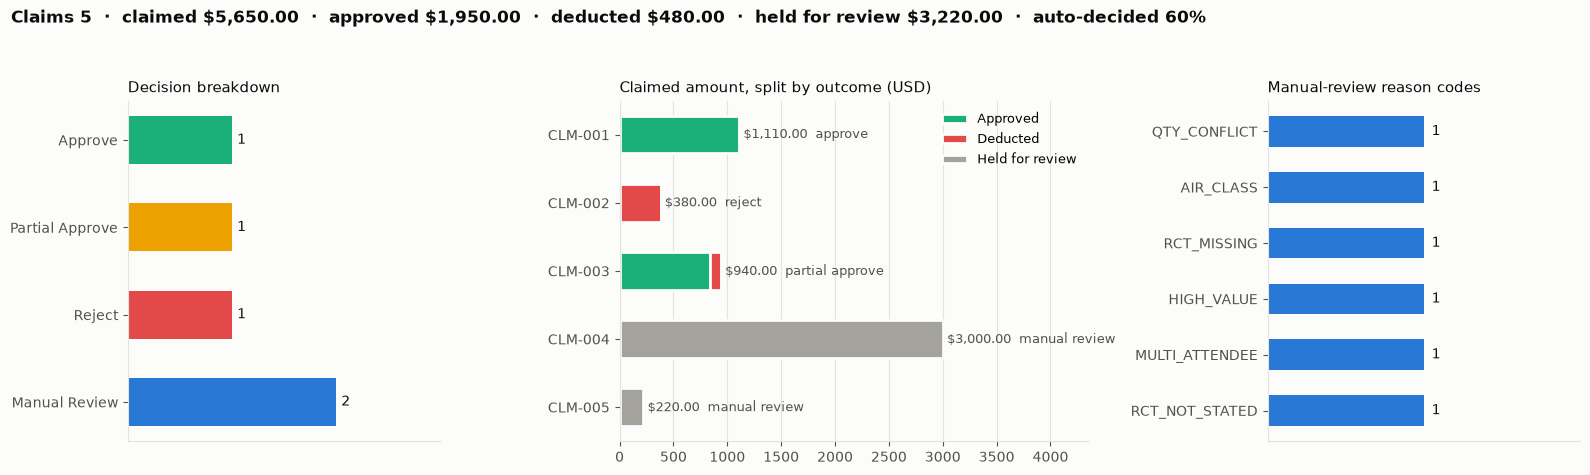

,claim_id,decision,approved_amount,deducted_amount,confidence,review_codes
0,CLM-001,APPROVE,1110.0,0.0,0.95,–
1,CLM-002,REJECT,0.0,380.0,0.95,–
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.95,–
3,CLM-004,MANUAL_REVIEW,0.0,0.0,0.95,"QTY_CONFLICT, AIR_CLASS, RCT_MISSING, HIGH_VALUE"
4,CLM-005,MANUAL_REVIEW,0.0,0.0,0.80,"MULTI_ATTENDEE, RCT_NOT_STATED"


In [13]:
import matplotlib.pyplot as plt

plt.rcParams["text.parse_math"] = False  # "$" in labels is currency, not mathtext

COLORS = {"APPROVE": "#1baf7a", "PARTIAL_APPROVE": "#eda100", "REJECT": "#e34948", "MANUAL_REVIEW": "#2a78d6"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"


def draw_dashboard(results: list[dict], audits: dict, path: str | None = None):
    df = pd.DataFrame(results)
    df["claimed"] = df["claim_id"].map(lambda c: CLAIM_STORE[c].total_claimed)
    df["held"] = (df["claimed"] - df["approved_amount"] - df["deducted_amount"]).clip(lower=0)
    counts = df["decision"].value_counts().reindex(DECISIONS, fill_value=0)
    codes = pd.Series([c for cid in df["claim_id"] for c in audits[cid]["floor"]["review_codes"]]).value_counts()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1, 1.5, 1]})
    fig.patch.set_facecolor("#fcfcfb")
    auto = (df["decision"] != "MANUAL_REVIEW").mean()
    fig.suptitle(f"Claims {len(df)}  ·  claimed {money(df['claimed'].sum())}  ·  approved {money(df['approved_amount'].sum())}  ·  "
                 f"deducted {money(df['deducted_amount'].sum())}  ·  held for review {money(df['held'].sum())}  ·  auto-decided {auto:.0%}",
                 x=0.01, ha="left", fontsize=12, color=INK, fontweight="bold")

    ax = axes[0]
    labels = [d.replace("_", " ").title() for d in DECISIONS]
    ax.barh(labels, counts.values, color=[COLORS[d] for d in DECISIONS], height=0.55)
    for y, v in enumerate(counts.values):
        ax.text(v + 0.05, y, str(v), va="center", color=INK, fontsize=10)
    ax.invert_yaxis()
    ax.set_title("Decision breakdown", loc="left", color=INK, fontsize=11)
    ax.set_xlim(0, counts.max() + 1)
    ax.set_xticks([])

    ax = axes[1]
    left = pd.Series(0.0, index=df.index)
    for col, color, name in (("approved_amount", COLORS["APPROVE"], "Approved"), ("deducted_amount", COLORS["REJECT"], "Deducted"), ("held", "#a3a29c", "Held for review")):
        ax.barh(df["claim_id"], df[col], left=left, color=color, height=0.55, label=name, edgecolor="#fcfcfb", linewidth=2)
        left += df[col]
    for y, (_, r) in enumerate(df.iterrows()):
        ax.text(r["claimed"] + 40, y, f"{money(r['claimed'])}  {r['decision'].replace('_', ' ').lower()}", va="center", color=MUTED, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, df["claimed"].max() * 1.45)
    ax.set_title("Claimed amount, split by outcome (USD)", loc="left", color=INK, fontsize=11)
    ax.legend(loc="upper right", frameon=False, fontsize=9)
    ax.grid(axis="x", color=GRID)
    ax.set_axisbelow(True)

    ax = axes[2]
    if len(codes):
        ax.barh(codes.index, codes.values, color=COLORS["MANUAL_REVIEW"], height=0.55)
        for y, v in enumerate(codes.values):
            ax.text(v + 0.05, y, str(v), va="center", color=INK, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlim(0, codes.max() + 1)
    ax.set_title("Manual-review reason codes", loc="left", color=INK, fontsize=11)
    ax.set_xticks([])

    for ax in axes:
        ax.set_facecolor("#fcfcfb")
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        ax.spines["left"].set_color(GRID)
        ax.spines["bottom"].set_color(GRID)
        ax.tick_params(colors=MUTED)
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    if path:
        fig.savefig(path, dpi=150, facecolor=fig.get_facecolor())
    plt.show()


draw_dashboard(RESULTS, AUDITS, path="UI SS_1.png")
display(pd.DataFrame(RESULTS)[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence"]]
        .assign(review_codes=[", ".join(AUDITS[r["claim_id"]]["floor"]["review_codes"]) or "–" for r in RESULTS]))

### Interactive claim evaluator
Pick a sample claim or paste any claim JSON in the same shape, edit it (for example set CLM-005's `receipt_attached` to
`true`, or change CLM-003's lodging to `400`), and press **Evaluate claim**. The claim goes through the same intake
validation, agent, validator and audit trail. Edited claims are added to the session dashboard.

*(Widgets need a live kernel, so they do not render on GitHub. The static dashboard above does.)*

In [14]:
import ipywidgets as w

picker = w.Dropdown(options=SAMPLE_IDS, value=SAMPLE_IDS[0], description="Sample:")
editor = w.Textarea(layout=w.Layout(width="100%", height="300px"))
run_btn = w.Button(description="Evaluate claim", button_style="primary", icon="check")
dash_btn = w.Button(description="Refresh dashboard", icon="bar-chart")
out = w.Output()


def _load_sample(_=None):
    editor.value = CLAIM_STORE[picker.value].model_dump_json(indent=2)


def _evaluate(_):
    out.clear_output()
    with out:
        try:
            (cid,) = intake(editor.value)
        except (ValueError, ValidationError) as e:
            print(f"Claim rejected at intake. Fix the JSON and retry:\n{e}")
            return
        result, audit = evaluate_claim(cid)
        AUDITS[cid] = audit
        RESULTS[:] = [r for r in RESULTS if r["claim_id"] != cid] + [result]
        display(Markdown(decision_card(result)))
        show_audit(cid)
        print(json.dumps(result, indent=2))


def _refresh(_):
    out.clear_output()
    with out:
        draw_dashboard(RESULTS, AUDITS)


picker.observe(_load_sample, names="value")
run_btn.on_click(_evaluate)
dash_btn.on_click(_refresh)
_load_sample()
display(w.VBox([w.HTML("<b>Travel claim evaluator</b>"), picker, editor, w.HBox([run_btn, dash_btn]), out]))

## Design Notes & Reasoning

### Architecture in one line
**The LLM plans, grounds and explains. Deterministic tools compute. A validator decides what the LLM is allowed to change.**

```
claim JSON ──► intake (Pydantic) ──► agent loop ──► submit_decision ──► validate_decision ──► ClaimDecision (exact schema)
                                        │  ▲                                  ▲
                                        ▼  │ tool results                    │ rule_floor (same tools, every check)
                       lookup_policy · check_eligibility · check_receipts · check_limits · check_timeliness · check_approval_tier
```

### Why this split
* **Money is arithmetic, not generation.** Per-diem caps × nights, tier thresholds and receipt thresholds are exact rules.
  An LLM that does them in its head will occasionally get one wrong, and an auditor cannot tell which time. So every amount
  in the output comes from a tool, and the model is told to quote the figures, not compute them.
* **The LLM earns its place on judgment.** That covers deciding which rules apply, reading free-text descriptions ("dinner
  for 4", "weekend hotel stay"), noticing what the structured fields miss, and writing an explanation a reviewer can act on.
  It may raise `concerns` and escalate to Manual Review on them (`AGENT_ESCALATION`).
* **Asymmetric authority.** The validator lets the agent make a decision *stricter* (escalate to review) but never *looser*.
  If the agent proposes APPROVE where the tools force MANUAL_REVIEW, or proposes the wrong non-review outcome, the rule
  floor wins, confidence drops to 0.60, and the override is written to the audit trail. A hallucination can therefore cost
  a reviewer some time, but it cannot pay out money.
* **Two modes, one contract.** The rules-only planner exists so the notebook runs with no key and no network. It also shows
  the rule floor on its own is sound: it reaches 5/5 on the sample claims. The LLM path adds orchestration, natural-language
  judgment and better explanations on top. It is not needed for correctness.

### Why these cases go to Manual Review
| Claim | Triggers | Reasoning |
|---|---|---|
| CLM-004 | `AIR_CLASS`, `RCT_MISSING`, `QTY_CONFLICT`, `HIGH_VALUE` | POL-AIR-01 says business class must not be auto-deducted, because a pre-approval may exist. The hotel receipt is missing (POL-RCT-02 says request it, do not reject). The $3,000 total is above the agent's authority (POL-APR-03). The line also claims **3 nights for a 06-16 → 06-18 trip, which is 2 nights**. At 2 nights, $600 is $300/night and $200 over the cap; at 3 nights it is exactly at the cap. The data conflicts, so the agent asks rather than picks. |
| CLM-005 | `RCT_NOT_STATED`, `MULTI_ATTENDEE` | The claim does not say whether a receipt is attached for a $220 meal, which POL-RCT-01 requires. A mechanical reading would PARTIAL_APPROVE $75 and deduct $145. But the meal is a client dinner for 4, and the per-diem is a per-day cap for the traveller; the policy does not cover hosting. Forcing a deduction would be a guess, so it goes to a person. |

The other three are decided automatically because nothing in them is uncertain. CLM-003's $100 deduction is a plain
POL-PD-02 cap. CLM-002 contains only POL-CAT-02 items.

### Assumptions
* **Expense date = trip start** for POL-TIME-01. Lines carry no dates, so this is the strictest reading. Every sample claim
  is 10–14 days old, so none is late.
* **Trip dates set the cap size**: nights = end − start, days = nights + 1. A quantity stated in the description is used when
  it is *not more* than the trip allows (CLM-003 claims meals for 2 of 3 days, which is fine). If the stated quantity is
  higher, that is a conflict.
* **Per-diem caps are applied to the line total over its days or nights.** There is no per-day breakdown, so a line within
  `cap × units` is treated as compliant.
* **For Manual Review, `approved_amount = 0`** (the agent approves nothing) and `deducted_amount` holds only *certain*
  deductions: ineligible items and over-cap amounts on lines with no ambiguity. Uncertain excess is left for the reviewer.
* **CLM-005 transcription.** The line amount is taken from the claim total, and the receipt status is `null`, because
  Appendix B leaves both cells blank.
* Ineligible lines are not checked for receipts; they are deducted in full either way.

### Trade-offs
* **Keyword retrieval, not embeddings.** Twelve short rules fit in one prompt. A vector store would add a dependency and
  nondeterminism with no gain in recall. The tool interface (`lookup_policy(query)`) stays the same if the policy grows and
  needs embeddings or BM25.
* **Regex for "N nights" and "for N".** This is cheap, deterministic and covers the sample phrasing. An LLM extraction step
  would generalise better, but its output would then need its own validation. The agent's `concerns` channel covers
  phrasings the regex misses.
* **OpenAI-compatible client only.** One code path covers Groq, Gemini, OpenAI, Ollama and any local server. Provider-specific
  features such as strict JSON schema mode are not used.
* **Confidence is a rule-based heuristic** (0.95 / 0.80 / 0.75 / 0.60). It is explainable and repeatable. It is not a
  statistically calibrated probability, and self-reported LLM confidence is deliberately left out.

### Known gaps
* No OCR or receipt parsing. Receipt metadata is taken as declared on the claim.
* No duplicate-claim detection across submissions. With one session's claims there is nothing to compare against.
* No currency conversion (all claims are USD), and no business-purpose classifier. A personal-looking purpose on otherwise
  eligible items would only be caught through the LLM's `concerns`.
* The fallback triggers on an exception, not on poor quality. A weak local model that calls few tools still gets corrected
  by the validator, but its explanation may be thin.

### What I would improve next
1. A labelled evaluation set (around 50 synthetic claims covering each reason code and edge case), run per model and per
   prompt change, with decision accuracy and override rate tracked.
2. Receipt ingestion: extract vendor, date, amount and line items from attachments, and reconcile them with the claim.
3. Per-line expense dates and per-day meal breakdowns, so caps apply per calendar day.
4. A reviewer workflow: Manual Review items go to a queue, and the reviewer's resolution is fed back as labelled data.
5. Expose the tools over MCP so the same checks serve a chat UI, an approval portal and batch jobs.

## Final structured results

In [15]:
FINAL_RESULTS = sorted((r for r in RESULTS if r["claim_id"] in SAMPLE_IDS), key=lambda r: SAMPLE_IDS.index(r["claim_id"]))
print(json.dumps(FINAL_RESULTS, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-APR-02"
    ],
    "confidence": 0.95,
    "explanation": "Approved in full. Lodging $360.00 for 2 night(s) is within the $200.00/night cap (POL-PD-02). Meals $180.00 for 3 day(s) is within the $75.00/day cap (POL-PD-01). Reimbursable total $1,110.00 falls in the manager tier (POL-APR-02).",
    "tools_used": [
      "lookup_policy",
      "check_eligibility",
      "check_receipts",
      "check_limits",
      "check_timeliness",
      "check_approval_tier",
      "validate_decision"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.95,
    "explanation": "Rejected: nothing in the claim is re